<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_RNN_pt2.ipynb)

# Multivariate Occupancy Example (RNN), Part 2: Reload and Test on Unseen Data
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Part 1 trained on two weeks of sensor data and saved the stacked RNN. The UCI dataset ships a **third file** - two more days the model has never seen (`datatest.txt`). This notebook downloads the saved model, scores those unseen days, and then explains the classifier: which **sensor** it trusts, which **minutes** of the window it reads, and what happens when you crank the CO2.

No training here. Everything is inference on an artifact.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10-pt2 — Multivariate RNN Pt 2b: reload the classifier, score two unseen days, explain it
- Download the .keras Part 1 saved; rebuild the windows the same way (10 minutes, 5 sensors, occupancy last). Prove it still gives Part 1's numbers on Part 1's test split.
- Unseen data: datatest.txt - two days the model never met (they're from BEFORE the training week; fine for a nowcast, and say why it would NOT be fine for a forecast). 97.4% accuracy on the unseen days vs 94.1% on Part 1's split - and persistence is still 0.99 weighted F1. Read the confusion matrix against persistence again.
- Permutation by sensor: shuffle Light across windows and the classifier collapses; shuffle Temperature and nothing happens. The model found the light switch. Ask: is that a good feature or a shortcut? (Night-time meetings...)
- Occlusion by minute: which of the ten minutes matter? For a nowcast it's the LAST minute; the window barely helps. Connect to the persistence baseline being 99%.
- What-if: +300 ppm CO2 moves P(occupied) by +0.008; +200 lux moves it +0.147 and flips 5% of windows; +2 C does nothing. Counterfactuals are the interpretability tool managers actually understand.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, f1_score
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)

## Rebuild Part 1's prep, then load the unseen file the same way

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

The multivariate version. Put the **target in the last column** first, then:

- **`n_steps`** is the **look-back**: each X is the last `n_steps` rows of **every column except the target**, shaped `(n_steps, n_features)`.
- The target y is the **last column at the final row of the window**, the same moment as the newest inputs.

For occupancy that's a **nowcast**: the sensors up to this minute say whether the room is occupied this minute.

Result: X is `(samples, n_steps, n_features)`, exactly what `input_shape=(n_steps, n_features)` expects.


In [2]:
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
def prep(files):
    d = pd.concat([pd.read_csv(base + f) for f in files], ignore_index=True).sort_values("date").reset_index(drop=True)
    return d.drop(columns=["date"])                    # Temperature, Humidity, Light, CO2, HumidityRatio, Occupancy (LAST)

def split_sequences(sequences, n_steps):
    X, y = [], []
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences): break
        X.append(sequences[i:end_ix, :-1]); y.append(sequences[end_ix-1, -1])   # sensors in, occupancy NOW out (a nowcast)
    return np.array(X), np.array(y)

n_steps = 10
df = prep(["datatraining.txt", "datatest2.txt"])        # Part 1's two weeks
sensors = list(df.columns[:-1])
X, y = split_sequences(df.values, n_steps)
cut = int(0.5 * len(X)); X_test, y_test = X[cut:], y[cut:]

new = prep(["datatest.txt"])                            # the third file: two days the model has never seen
X_new, y_new = split_sequences(new.values, n_steps)
print("Part 1 test:", X_test.shape, "| unseen:", X_new.shape, "| unseen occupied share:", round(y_new.mean(), 2))

Part 1 test: (8943, 10, 5) | unseen: (2656, 10, 5) | unseen occupied share: 0.36


## Download the saved model and prove it's the same one

In [3]:
import os
fname = "Multivariate_Occupancy_RNN.keras"
if os.path.exists(fname):
    os.remove(fname)          # never load a stale copy left over from an earlier run
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Multivariate_Occupancy_RNN.keras", fname)
print(f"downloaded {os.path.getsize(fname):,} bytes")

model = load_model(fname)
model.summary()

downloaded 27,704 bytes


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,825 (34.48 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,884 (22.99 KB)

In [4]:
p_test = np.round(model.predict(X_test, verbose=0)).ravel()
print("Part 1's test split, reloaded model:")
print(classification_report(y_test, p_test, digits=3))

Part 1's test split, reloaded model:
              precision    recall  f1-score   support

         0.0      0.963     0.963     0.963      7108
         1.0      0.857     0.855     0.856      1835

    accuracy                          0.941      8943
   macro avg      0.910     0.909     0.909      8943
weighted avg      0.941     0.941     0.941      8943



## Score the unseen days

UNSEEN two days:
[[1636   57]
 [  13  950]]
              precision    recall  f1-score   support

         0.0      0.992     0.966     0.979      1693
         1.0      0.943     0.987     0.964       963

    accuracy                          0.974      2656
   macro avg      0.968     0.976     0.972      2656
weighted avg      0.974     0.974     0.974      2656

persistence baseline on the unseen days - weighted F1: 0.990


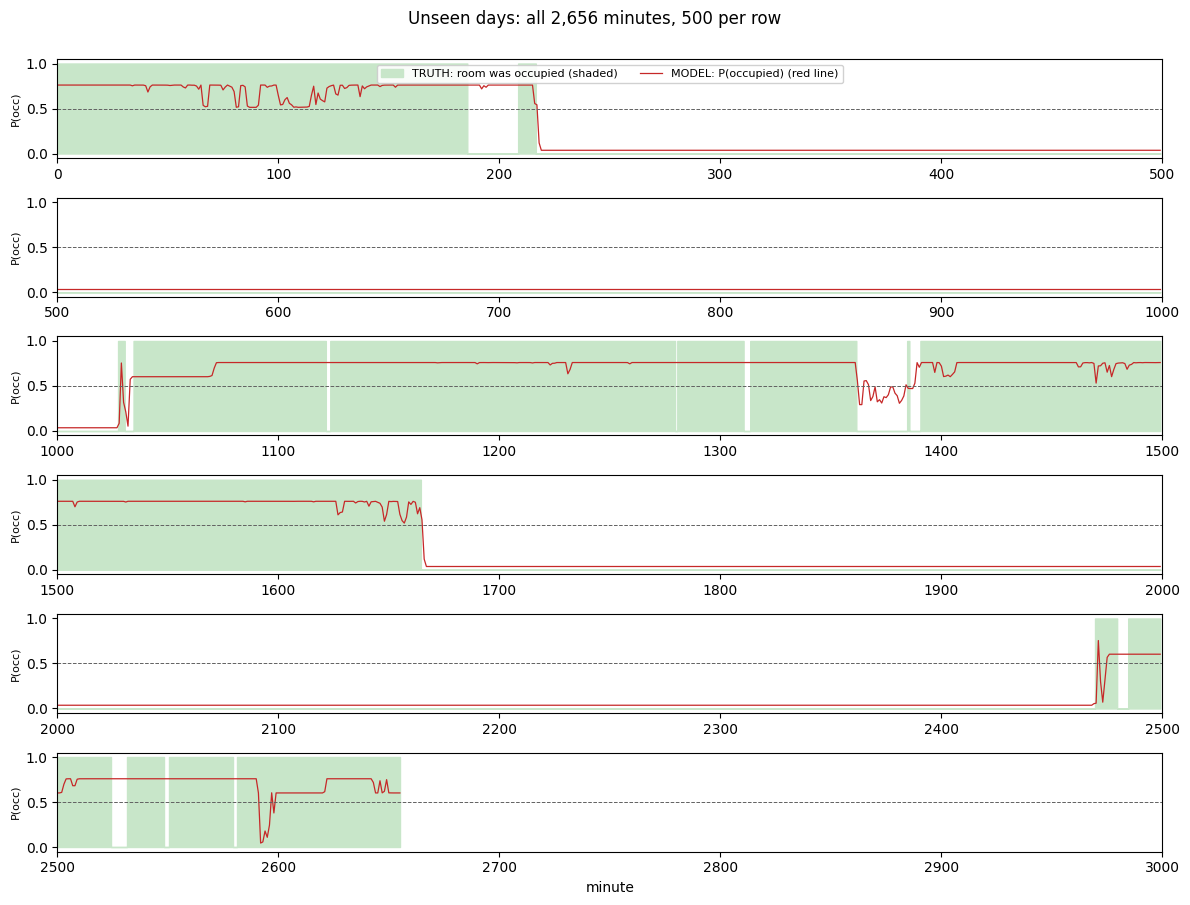

In [5]:
prob_new = model.predict(X_new, verbose=0).ravel()
p_new = np.round(prob_new)
print("UNSEEN two days:")
print(confusion_matrix(y_new, p_new))
print(classification_report(y_new, p_new, digits=3))
persist = np.r_[y_new[0], y_new[:-1]]                                       # "same as a minute ago"
print(f"persistence baseline on the unseen days - weighted F1: {f1_score(y_new, persist, average='weighted'):.3f}")

CHUNK = 500              # the whole unseen stretch, wrapped onto rows - nothing hidden in a slice
nrow = int(np.ceil(len(y_new) / CHUNK))
fig, ax = plt.subplots(nrow, 1, figsize=(12, 1.5 * nrow), squeeze=False)
for k in range(nrow):
    sl = slice(k * CHUNK, min((k + 1) * CHUNK, len(y_new)))
    t = np.arange(len(y_new))[sl]
    ax[k][0].fill_between(t, 0, y_new[sl], step="mid", color="#C8E6C9",
                          label="TRUTH: room was occupied (shaded)" if k == 0 else None)
    ax[k][0].plot(t, prob_new[sl], color="#C62828", lw=0.9,
                  label="MODEL: P(occupied) (red line)" if k == 0 else None)
    ax[k][0].axhline(0.5, color="#616161", ls="--", lw=0.7)
    ax[k][0].set_ylim(-0.05, 1.05); ax[k][0].set_yticks([0, 0.5, 1])
    ax[k][0].set_xlim(k * CHUNK, (k + 1) * CHUNK); ax[k][0].set_ylabel("P(occ)", fontsize=8)
ax[0][0].legend(loc="upper center", ncol=2, fontsize=8, framealpha=0.9)
ax[-1][0].set_xlabel("minute")
fig.suptitle(f"Unseen days: all {len(y_new):,} minutes, {CHUNK} per row", y=1.0)
plt.tight_layout(); plt.show()

### Scored three ways on the unseen days

Same `metrics_table` as Part 1, so the numbers line up directly. Three rows to compare: the model, the persistence
baseline it has to beat, and the do-nothing baseline that never says "occupied".

Watch **macro F1** rather than accuracy - the unseen days are imbalanced too, so accuracy flatters the naive baseline.

In [6]:
def metrics_table(y_true_cls, y_pred_cls, labels=("empty", "occupied")):
    """Every intermediate number behind accuracy / macro F1 / weighted F1 - shown, not asserted.
    Same helper as Part 1, so the two notebooks are directly comparable."""
    y_true_cls = np.asarray(y_true_cls).astype(int).ravel()
    y_pred_cls = np.asarray(y_pred_cls).astype(int).ravel()
    rows = []
    for k, cname in enumerate(labels):
        tp = int(((y_pred_cls == k) & (y_true_cls == k)).sum())
        fp = int(((y_pred_cls == k) & (y_true_cls != k)).sum())
        fn = int(((y_pred_cls != k) & (y_true_cls == k)).sum())
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        n_c  = int((y_true_cls == k).sum())
        rows.append({"class": cname, "TP": tp, "FP": fp, "FN": fn, "precision": round(prec, 4),
                     "recall": round(rec, 4), "F1": round(f1, 4), "support n_c": n_c,
                     "n_c x F1": round(n_c * f1, 1)})
    t = pd.DataFrame(rows).set_index("class")
    N = int(t["support n_c"].sum()); correct = int((y_pred_cls == y_true_cls).sum())
    macro = t["F1"].mean(); weighted = t["n_c x F1"].sum() / N
    display(t)
    print(f"accuracy    = correct / all     = {correct:,} / {N:,} = {correct/N:.4f}")
    print(f"macro F1    = (F1_0 + F1_1) / 2 = ({t['F1'].iloc[0]:.4f} + {t['F1'].iloc[1]:.4f}) / 2 = {macro:.4f}")
    print(f"weighted F1 = sum(n_c x F1) / N = {t['n_c x F1'].sum():,.1f} / {N:,} = {weighted:.4f}")
    return {"accuracy": correct/N, "macro F1": macro, "weighted F1": weighted}


print("=" * 62); print("THE RELOADED MODEL, ON TWO DAYS IT HAS NEVER SEEN"); print("=" * 62)
m_model = metrics_table(y_new, p_new)

print(); print("=" * 62); print("PERSISTENCE: 'same as a minute ago'"); print("=" * 62)
m_persist = metrics_table(y_new, persist)

print(); print("=" * 62); print("THE DO-NOTHING BASELINE: always guess 'empty'"); print("=" * 62)
m_naive = metrics_table(y_new, np.zeros(len(y_new)))

print()
display(pd.DataFrame({"reloaded model": m_model, "persistence": m_persist,
                      "always guess empty": m_naive}).round(3))

THE RELOADED MODEL, ON TWO DAYS IT HAS NEVER SEEN


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,1636,13,57,0.9921,0.9663,0.9791,1693,1657.5
occupied,950,57,13,0.9434,0.9865,0.9645,963,928.8


accuracy    = correct / all     = 2,586 / 2,656 = 0.9736
macro F1    = (F1_0 + F1_1) / 2 = (0.9791 + 0.9645) / 2 = 0.9718
weighted F1 = sum(n_c x F1) / N = 2,586.3 / 2,656 = 0.9738

PERSISTENCE: 'same as a minute ago'


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,1680,13,13,0.9923,0.9923,0.9923,1693,1680.0
occupied,950,13,13,0.9865,0.9865,0.9865,963,950.0


accuracy    = correct / all     = 2,630 / 2,656 = 0.9902
macro F1    = (F1_0 + F1_1) / 2 = (0.9923 + 0.9865) / 2 = 0.9894
weighted F1 = sum(n_c x F1) / N = 2,630.0 / 2,656 = 0.9902

THE DO-NOTHING BASELINE: always guess 'empty'


,TP,FP,FN,precision,recall,F1,support n_c,n_c x F1
class,,,,,,,,
empty,1693,963,0,0.6374,1.0,0.7786,1693,1318.1
occupied,0,0,963,0.0000,0.0,0.0000,963,0.0


accuracy    = correct / all     = 1,693 / 2,656 = 0.6374
macro F1    = (F1_0 + F1_1) / 2 = (0.7786 + 0.0000) / 2 = 0.3893
weighted F1 = sum(n_c x F1) / N = 1,318.1 / 2,656 = 0.4963



,reloaded model,persistence,always guess empty
accuracy,0.974,0.990,0.637
macro F1,0.972,0.989,0.389
weighted F1,0.974,0.990,0.496


## What "importance" even means when a sample is a grid

Every sample the model sees is a **10 x 5 block**: ten minutes down, five sensors across.

|  | Temperature | Humidity | Light | CO2 | HumidityRatio |
| :-- | :-: | :-: | :-: | :-: | :-: |
| **t-9** | . | . | . | . | . |
| ... | . | . | . | . | . |
| **t-0** | . | . | . | . | . |

So "what mattered?" splits into two different questions. **Neither tool deletes anything** - the model is always
handed a complete 10 x 5 block. We **corrupt one slice of it on purpose** and measure what accuracy is lost:

- **Permutation scrambles a COLUMN.** Take one sensor and shuffle it across windows, so window 37 gets
  some other window's ten minutes of Light. The sensor still has its normal range and its normal shape - it is just
  no longer *this* window's Light. Whatever F1 disappears is what the model was getting from that sensor.
- **Occlusion blanks out a ROW.** Take one minute and overwrite **all five sensors at once** with their training-set
  averages. That minute is now a bland, uninformative moment. Whatever F1 disappears is what the model was getting
  from that position in the window.

So yes - occluding t-3 replaces the reading of *every* sensor at t-3, not just one. And permuting Light scrambles
it at *every* one of the ten minutes, not just one. They cut the grid in perpendicular directions.

**Why shuffle for one and average for the other?** Shuffling keeps a sensor realistic - real values, real dynamics,
wrong window - which is what you want when you are asking whether a *variable* carries signal. Averaging a minute
is the gentlest way to say "nothing happened here", which is what you want when you are asking whether a *moment*
carries signal. Deleting either one outright is not an option: the model demands a full 10 x 5 block.

**One thing to be clear about before reading the occlusion chart:** the target of this notebook is occupancy at the
**last minute of the window**, so `t-0` is not a lag at all - it is the very minute being classified. `t-1` is one
minute earlier, `t-9` is the oldest. (That is different from the temperature notebook, where the target was the
*next* value and every input really was a lag.)


## 1. Permutation importance by sensor (scramble a column)

Shuffle one sensor across the unseen windows and re-score. The F1 that disappears is how much the classifier
depended on that sensor. Watch which one carries the model - and then ask whether that is a *feature* or a
*shortcut*.

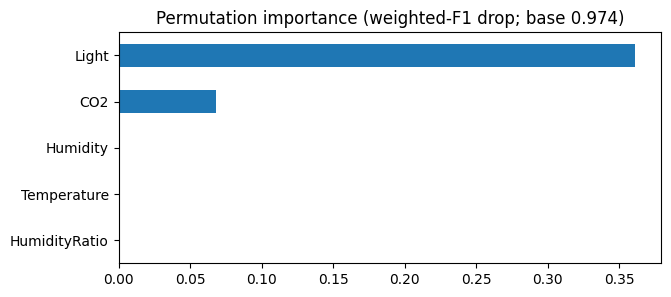

In [7]:
rng = np.random.default_rng(5509)
base_f1 = f1_score(y_new, p_new, average="weighted")
drop = {}
for j, s in enumerate(sensors):
    Xp = X_new.copy(); Xp[:, :, j] = Xp[rng.permutation(len(Xp)), :, j]
    drop[s] = base_f1 - f1_score(y_new, np.round(model.predict(Xp, verbose=0)).ravel(), average="weighted")
pd.Series(drop).sort_values().plot(kind="barh", figsize=(7, 3), title=f"Permutation importance (weighted-F1 drop; base {base_f1:.3f})"); plt.show()

## 2. Occlusion by minute (blank out a row)

Blank one minute of the 10-minute window - **all five sensors replaced by their training averages** - and re-score.
This tells you *where in the window* the model is looking, which permutation importance cannot.

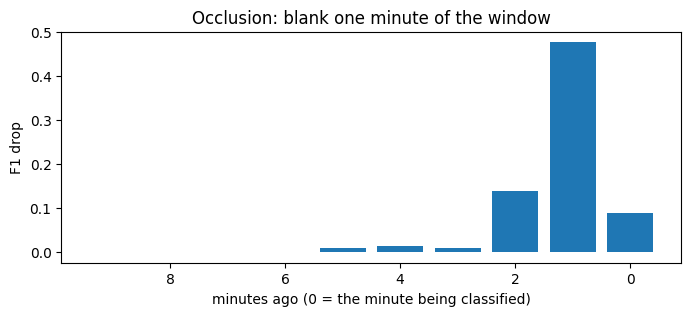

In [8]:
means = X[:cut].reshape(-1, X.shape[2]).mean(axis=0)
occ = []
for t in range(n_steps):
    Xo = X_new.copy(); Xo[:, t, :] = means
    occ.append(base_f1 - f1_score(y_new, np.round(model.predict(Xo, verbose=0)).ravel(), average="weighted"))
mins_ago = np.arange(n_steps - 1, -1, -1)
plt.figure(figsize=(8, 3)); plt.bar(mins_ago, occ); plt.gca().invert_xaxis()
plt.xlabel("minutes ago (0 = the minute being classified)"); plt.ylabel("F1 drop"); plt.title("Occlusion: blank one minute of the window"); plt.show()

## 3. What-if: crank the CO2, flip the lights

Add 300 ppm of CO2 to every window and read the change in P(occupied). Then add 200 lux of light. Which one does the model believe?

In [9]:
def whatif(delta, sensor):
    Xw = X_new.copy(); Xw[:, :, sensors.index(sensor)] += delta
    return model.predict(Xw, verbose=0).ravel() - prob_new

for delta, s in [(300, "CO2"), (200, "Light"), (2, "Temperature")]:
    d = whatif(delta, s)
    print(f"+{delta} {s:12s} -> mean change in P(occupied): {d.mean():+.3f}   | share of windows that flip to 'occupied': {((prob_new < 0.5) & (prob_new + d >= 0.5)).mean():.1%}")

+300 CO2          -> mean change in P(occupied): +0.008   | share of windows that flip to 'occupied': 0.6%


+200 Light        -> mean change in P(occupied): +0.147   | share of windows that flip to 'occupied': 5.0%


+2 Temperature  -> mean change in P(occupied): -0.000   | share of windows that flip to 'occupied': 0.0%


## What you just saw

- The reloaded model gives Part 1's numbers **and** holds up on two days it never saw - that is the test that matters.
- It is mostly a **light detector** with CO2 as the second opinion; temperature and humidity barely register. Ask whether that generalizes to a room where people work with the lights off.
- For a *nowcast* the window barely matters - the last minute carries the answer, which is why persistence was 99%. The RNN earns its keep at the **transitions**, when someone walks in or out.

## On your own
- Score `Multivariate_Occupancy_RNN_AdvancedTopics.keras` (the ConvLSTM) on the same unseen days. More parameters, better?
- Shift the target: predict occupancy **5 minutes ahead** (`sequences[end_ix-1+5, -1]`). Now the window should matter - does it?